# Single cluster display

One expression cluster from the window-profile CSV. Set `EXAMPLE_CLUSTER_NUMBER` to choose the cluster. Plots use the presentation figure styling: monospace type, bold axis text, and a light y-grid.


## Setup


In [1]:
from __future__ import annotations

import re
import sys
import textwrap
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "monospace"
plt.rcParams["pdf.fonttype"] = 42

SPINE_COLOR = "#2b2b2b"
PROFILE_COLOR = "#1f77b4"


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def resolve_data_dir(root: Path, data_dir: str) -> Path:
    path = Path(data_dir)
    resolved = path if path.is_absolute() else (root / path)
    resolved = resolved.resolve()
    if not resolved.is_dir():
        raise FileNotFoundError(f"Data directory not found: {resolved}")
    return resolved


def latest_profile_csv(data_dir: Path) -> Path:
    filename = "window_sequence_profiles.csv"
    results_root = data_dir / "results"
    run_profiles = list((results_root / "runs").glob(f"*/{filename}"))
    if run_profiles:
        return max(run_profiles, key=lambda path: path.stat().st_mtime_ns)
    legacy_profile = results_root / filename
    if legacy_profile.is_file():
        return legacy_profile
    raise FileNotFoundError(
        f"No {filename} found in {results_root / 'runs'} or {results_root}."
    )


def style_axes(
    ax,
    *,
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    label_size: float = 10.5,
    title_size: float = 12,
) -> None:
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE_COLOR)
    ax.spines["bottom"].set_color(SPINE_COLOR)
    ax.grid(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5, zorder=0)
    ax.tick_params(labelsize=8.5, length=3.5, width=0.8, colors=SPINE_COLOR)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=label_size, fontweight="bold", labelpad=6)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_size, fontweight="bold", labelpad=6)
    if title is not None:
        ax.set_title(title, fontsize=title_size, fontweight="bold", pad=8)


def clean_cluster_title(name: str, width: int = 72) -> str:
    cleaned = name.removeprefix("Cluster ")
    return "\n".join(textwrap.wrap(cleaned, width=width)) or cleaned


ROOT = repo_root_from_here()
DATA_PATH = resolve_data_dir(ROOT, "data/skin_samples")
PROFILES_CSV = latest_profile_csv(DATA_PATH)

CLUSTER_COL = "single_cell_expression_cluster"
DELIMITER_COL = "profile_delimiter"
UNASSIGNED_LABEL = "(unassigned)"
MEAN_SIGMA_COLUMN = "hyperplane_distance_mean_profile"
MEAN_P_AMP_COLUMN = "p_amp_mean_profile"
EXAMPLE_CLUSTER_NUMBER = 106
# True writes every cluster figure except the per-sequence sigma traces.
SAVE_CLUSTER_PLOTS = True
SAVE_DPI = 300
CLUSTER_PLOT_DIR = ROOT / "results" / "per_cluster_plots" / str(EXAMPLE_CLUSTER_NUMBER)

# None keeps the activity boundary at sigma = 0. A probability is inverted through the SVM Platt fit.
P_AMP_FITTING: float | None = None
P_AMP_ACTIVITY_THRESHOLD: float | None = None
# Sequences with DNGC at or below this value are dropped. 0 keeps only DNGC > 0.
DNGC_MIN_THRESHOLD: float | None = 0.0
SVM_PKL = ROOT / "checkpoints" / "svm_no_class_weight" / "svm_qsar12_model.pkl"


def sigma_for_p_amp(p_amp: float, svm_pkl: Path) -> float:
    """Invert the SVM Platt fit so a P(AMP) decision boundary becomes a sigma."""
    if not 0.0 < p_amp < 1.0:
        raise ValueError(f"P_AMP_FITTING must be between 0 and 1, got {p_amp}.")
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    from window_sequence_analysis.models.svm import load_svm

    svm = load_svm(svm_pkl)
    classes = np.asarray(getattr(svm, "classes_", []))
    if classes.size != 2 or int(classes[-1]) != 1:
        raise ValueError(f"Expected a binary SVM with positive class 1, got classes {classes}.")
    prob_a = float(np.asarray(svm.probA_).ravel()[0])
    prob_b = float(np.asarray(svm.probB_).ravel()[0])
    if prob_a == 0.0:
        raise ValueError("SVM Platt slope probA_ is 0, so P(AMP) cannot be mapped to sigma.")
    return float((np.log((1.0 - p_amp) / p_amp) + prob_b) / prob_a)


SIGMA_ACTIVITY_THRESHOLD = 0.0 if P_AMP_FITTING is None else sigma_for_p_amp(P_AMP_FITTING, SVM_PKL)


def save_cluster_plot(fig, name: str) -> None:
    if not SAVE_CLUSTER_PLOTS:
        return
    CLUSTER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
    path = CLUSTER_PLOT_DIR / f"{name}.png"
    fig.savefig(path, dpi=SAVE_DPI)
    print("saved", path)


print("ROOT:", ROOT)
print("profiles:", PROFILES_CSV)
print("cluster:", EXAMPLE_CLUSTER_NUMBER)
print("sigma threshold:", f"{SIGMA_ACTIVITY_THRESHOLD:.2f}")
print(
    "DNGC threshold:",
    "not applied" if DNGC_MIN_THRESHOLD is None else f"> {DNGC_MIN_THRESHOLD:g}",
)
print("save cluster plots:", CLUSTER_PLOT_DIR if SAVE_CLUSTER_PLOTS else "off")


ROOT: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction
profiles: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/runs/2026-09-16_20-47/window_sequence_profiles.csv
cluster: 106
sigma threshold: 0.00
DNGC threshold: > 0
save cluster plots: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/results/per_cluster_plots/106


## Load one cluster

Profiles are read from the latest `window_sequence_profiles.csv`. Only sequences whose `single_cell_expression_cluster` matches `EXAMPLE_CLUSTER_NUMBER` and whose DNGC is above 0 are kept.


In [2]:
def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for index, part in enumerate(parts):
        token = part.strip()
        values[index] = np.nan if not token or token.lower() == "nan" else float(token)
    return values


def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_number_from_name(name: str) -> int | None:
    match = re.match(r"Cluster\s+(\d+)", name)
    return int(match.group(1)) if match else None


def activity_mask(sigma: np.ndarray, p_amp: np.ndarray) -> np.ndarray:
    mask = np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)
    if P_AMP_ACTIVITY_THRESHOLD is not None:
        mask &= np.isfinite(p_amp) & (p_amp > P_AMP_ACTIVITY_THRESHOLD)
    return mask


def count_fragments(active: np.ndarray) -> int:
    if active.size == 0 or not np.any(active):
        return 0
    padded = np.concatenate([[False], np.asarray(active, dtype=bool)])
    return int(np.count_nonzero(padded[1:] & ~padded[:-1]))


@dataclass(frozen=True)
class ActivityStatistics:
    s_score: int
    fragment_count: int
    potency_auc: float
    coverage: float
    dngc: float


def calculate_activity_statistics(
    sigma: np.ndarray,
    p_amp: np.ndarray,
    sequence_length: int,
) -> ActivityStatistics:
    active = activity_mask(sigma, p_amp)
    s_score = int(np.count_nonzero(active))
    fragment_count = count_fragments(active)
    excess = sigma[active] - SIGMA_ACTIVITY_THRESHOLD
    potency_auc = float(np.sum(excess)) if s_score else 0.0
    coverage = s_score / sequence_length if sequence_length else 0.0
    mean_dngc = potency_auc / s_score if s_score else 0.0
    return ActivityStatistics(
        s_score=s_score,
        fragment_count=fragment_count,
        potency_auc=potency_auc,
        coverage=coverage,
        dngc=mean_dngc,
    )


@dataclass
class SequenceProfile:
    id: str
    name: str
    cluster: str
    sequence_length: int
    sigma: np.ndarray
    p_amp: np.ndarray
    statistics: ActivityStatistics


@dataclass
class ClusterGroup:
    name: str
    profiles: list[SequenceProfile] = field(default_factory=list)
    excluded_count: int = 0

    @property
    def n(self) -> int:
        return len(self.profiles)


def load_profile_table(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {"id", "sequence_length", DELIMITER_COL, CLUSTER_COL, MEAN_SIGMA_COLUMN, MEAN_P_AMP_COLUMN}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    if frame.empty:
        raise ValueError(f"Window profile CSV is empty: {path}")
    return frame


def protein_dngc(row: pd.Series) -> float:
    delimiter = str(row[DELIMITER_COL] or ";")
    sigma = parse_profile(row[MEAN_SIGMA_COLUMN], delimiter)
    p_amp = parse_profile(row[MEAN_P_AMP_COLUMN], delimiter)
    return calculate_activity_statistics(sigma, p_amp, int(row["sequence_length"])).dngc


def exclude_proteins_below_dngc(frame: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    if DNGC_MIN_THRESHOLD is None:
        return frame, 0
    scores = frame.apply(protein_dngc, axis=1)
    kept = frame.loc[scores > DNGC_MIN_THRESHOLD].reset_index(drop=True)
    excluded = len(frame) - len(kept)
    print(
        f"DNGC > {DNGC_MIN_THRESHOLD:g}: excluded {excluded:,} of {len(frame):,} proteins"
    )
    return kept, excluded


def select_cluster_frame(frame: pd.DataFrame, number: int) -> pd.DataFrame:
    numbers = frame[CLUSTER_COL].map(cluster_label).map(cluster_number_from_name)
    selected = frame.loc[numbers == number].reset_index(drop=True)
    if selected.empty:
        available = sorted({int(value) for value in numbers.dropna().unique()})
        raise ValueError(f"Cluster {number} not found. Available cluster numbers: {available}")
    return selected


def sequences_from_frame(frame: pd.DataFrame) -> ClusterGroup:
    grouped: dict[str, ClusterGroup] = {}
    for row in frame.itertuples(index=False):
        label = cluster_label(getattr(row, CLUSTER_COL))
        delimiter = str(getattr(row, DELIMITER_COL) or ";")
        sigma = parse_profile(getattr(row, MEAN_SIGMA_COLUMN), delimiter)
        p_amp = parse_profile(getattr(row, MEAN_P_AMP_COLUMN), delimiter)
        sequence_length = int(getattr(row, "sequence_length"))
        if len(sigma) != sequence_length or len(p_amp) != sequence_length:
            raise ValueError(f"{row.id}: profile length does not match sequence_length={sequence_length}.")
        profile = SequenceProfile(
            id=str(getattr(row, "id")),
            name=str(getattr(row, "name", "") or "").strip(),
            cluster=label,
            sequence_length=sequence_length,
            sigma=sigma,
            p_amp=p_amp,
            statistics=calculate_activity_statistics(sigma, p_amp, sequence_length),
        )
        grouped.setdefault(label, ClusterGroup(name=label)).profiles.append(profile)
    if len(grouped) != 1:
        raise ValueError(f"Expected one cluster label, found {sorted(grouped)}.")
    return next(iter(grouped.values()))


cluster_frame = select_cluster_frame(load_profile_table(PROFILES_CSV), EXAMPLE_CLUSTER_NUMBER)
cluster_frame, excluded_count = exclude_proteins_below_dngc(cluster_frame)
example_group = sequences_from_frame(cluster_frame)
example_group.excluded_count = excluded_count
print(f"Cluster {EXAMPLE_CLUSTER_NUMBER}: {example_group.name}")
print(f"Sequences: {example_group.n}    excluded: {example_group.excluded_count}")


DNGC > 0: excluded 5 of 7 proteins
Cluster 106: Cluster 106: Spermatogonia - Spermatogonial differentiation
Sequences: 2    excluded: 5


## Sigma profiles

Each sequence is the mean σNGC trace. The dashed line is DNGC = A / S, drawn above the activity threshold.


sp|Q6DHV7|ADAL_HUMAN
S = 6    F = 0.0169    A = 3.37    DNGC = 0.562


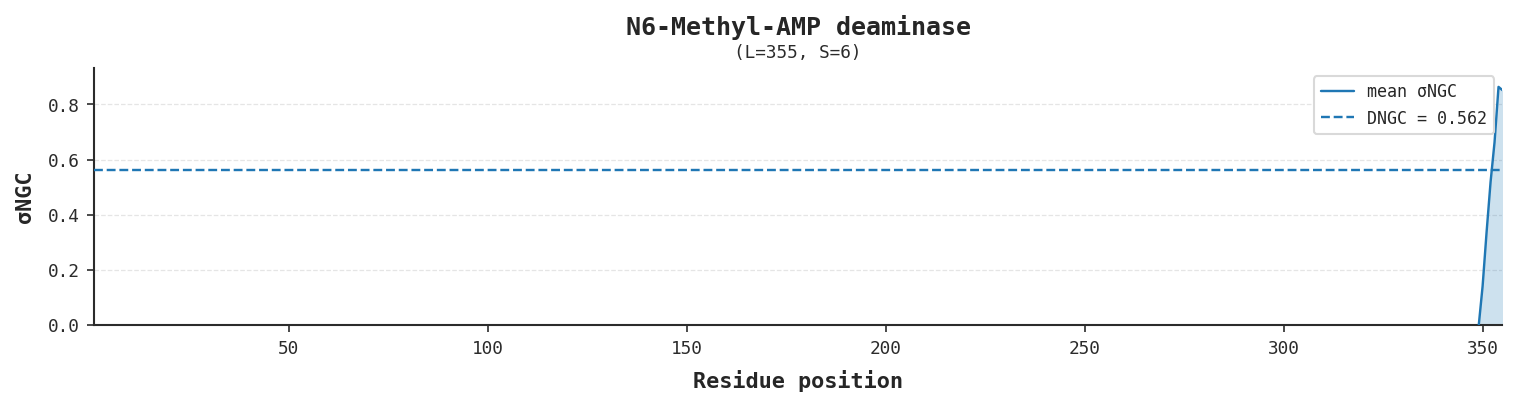

sp|Q02539|H11_HUMAN
S = 115    F = 0.535    A = 116    DNGC = 1.01


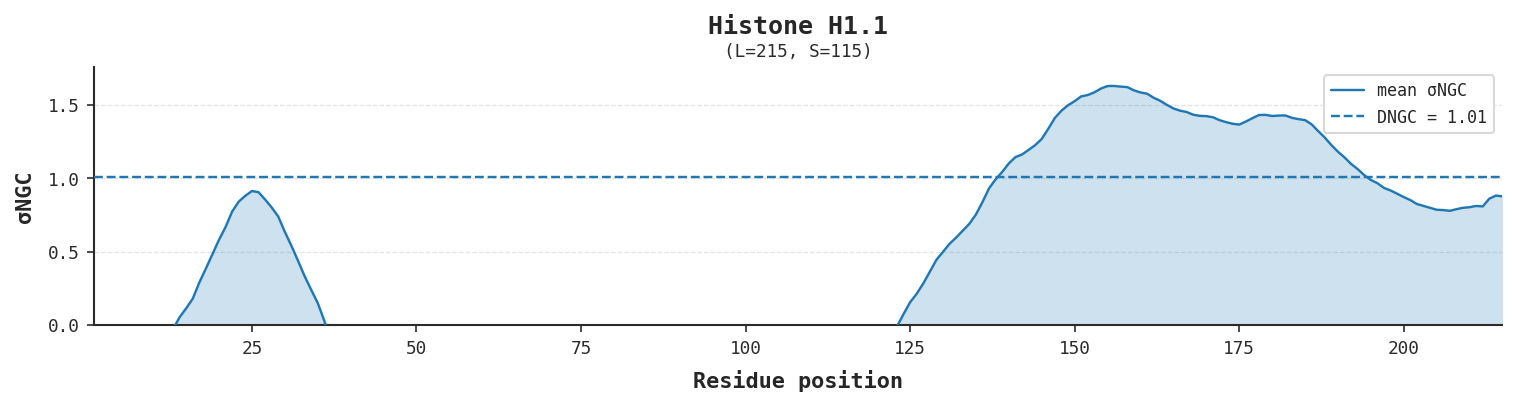

In [3]:
def _sigma_ylim(sigma: np.ndarray) -> tuple[float, float]:
    positive = sigma[np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)]
    baseline = SIGMA_ACTIVITY_THRESHOLD
    hi = float(np.max(positive)) if positive.size else baseline + 0.1
    span = max(hi - baseline, 0.1)
    return (baseline, hi + 0.08 * span)


def draw_sequence_sigma(ax, item: SequenceProfile) -> None:
    residue = np.arange(1, item.sequence_length + 1)
    sigma = np.nan_to_num(item.sigma, nan=0.0)
    active = activity_mask(item.sigma, item.p_amp)
    stats = item.statistics
    shown = np.where(active, np.maximum(sigma, SIGMA_ACTIVITY_THRESHOLD), SIGMA_ACTIVITY_THRESHOLD)
    ax.fill_between(
        residue,
        SIGMA_ACTIVITY_THRESHOLD,
        shown,
        color=PROFILE_COLOR,
        alpha=0.22,
        linewidth=0,
        zorder=2,
    )
    ax.plot(residue, sigma, color=PROFILE_COLOR, linewidth=1.15, zorder=3, label="mean σNGC")
    ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color=SPINE_COLOR, linewidth=0.8, zorder=1)
    if stats.s_score:
        ax.axhline(
            SIGMA_ACTIVITY_THRESHOLD + stats.dngc,
            color=PROFILE_COLOR,
            linewidth=1.15,
            linestyle="--",
            zorder=4,
            label=f"DNGC = {stats.dngc:.3g}",
        )
    style_axes(
        ax,
        xlabel="Residue position",
        ylabel="σNGC",
        title=f"{item.name}",
    )
    ax.set_title(f"{item.name}", fontsize=12, fontweight="bold", pad=16)
    ax.annotate(
        f"(L={item.sequence_length}, S={stats.s_score})",
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="normal",
        color=SPINE_COLOR,
        annotation_clip=False,
    )
    ax.set_xlim(1, item.sequence_length)
    ax.set_ylim(_sigma_ylim(sigma))
    ax.legend(
        fontsize=8,
        loc="upper right",
        frameon=True,
        framealpha=1.0,
        edgecolor="#d9d9d9",
        borderpad=0.4,
    )


for item in example_group.profiles:
    stats = item.statistics
    print(item.id)
    print(
        f"S = {stats.s_score}    F = {stats.coverage:.3g}    "
        f"A = {stats.potency_auc:.3g}    DNGC = {stats.dngc:.3g}"
    )
    _fig, ax = plt.subplots(figsize=(10.0, 2.6), dpi=150, layout="constrained")
    draw_sequence_sigma(ax, item)
    plt.show()


## Metric histograms

Per-sequence density of NGC, active residue count, potency area, and sequence coverage for this cluster. All four panels share one y-axis. Under the cluster name, the subtitle gives the plotted count and how many sequences were excluded.


saved /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/results/per_cluster_plots/106/metric_histograms.png


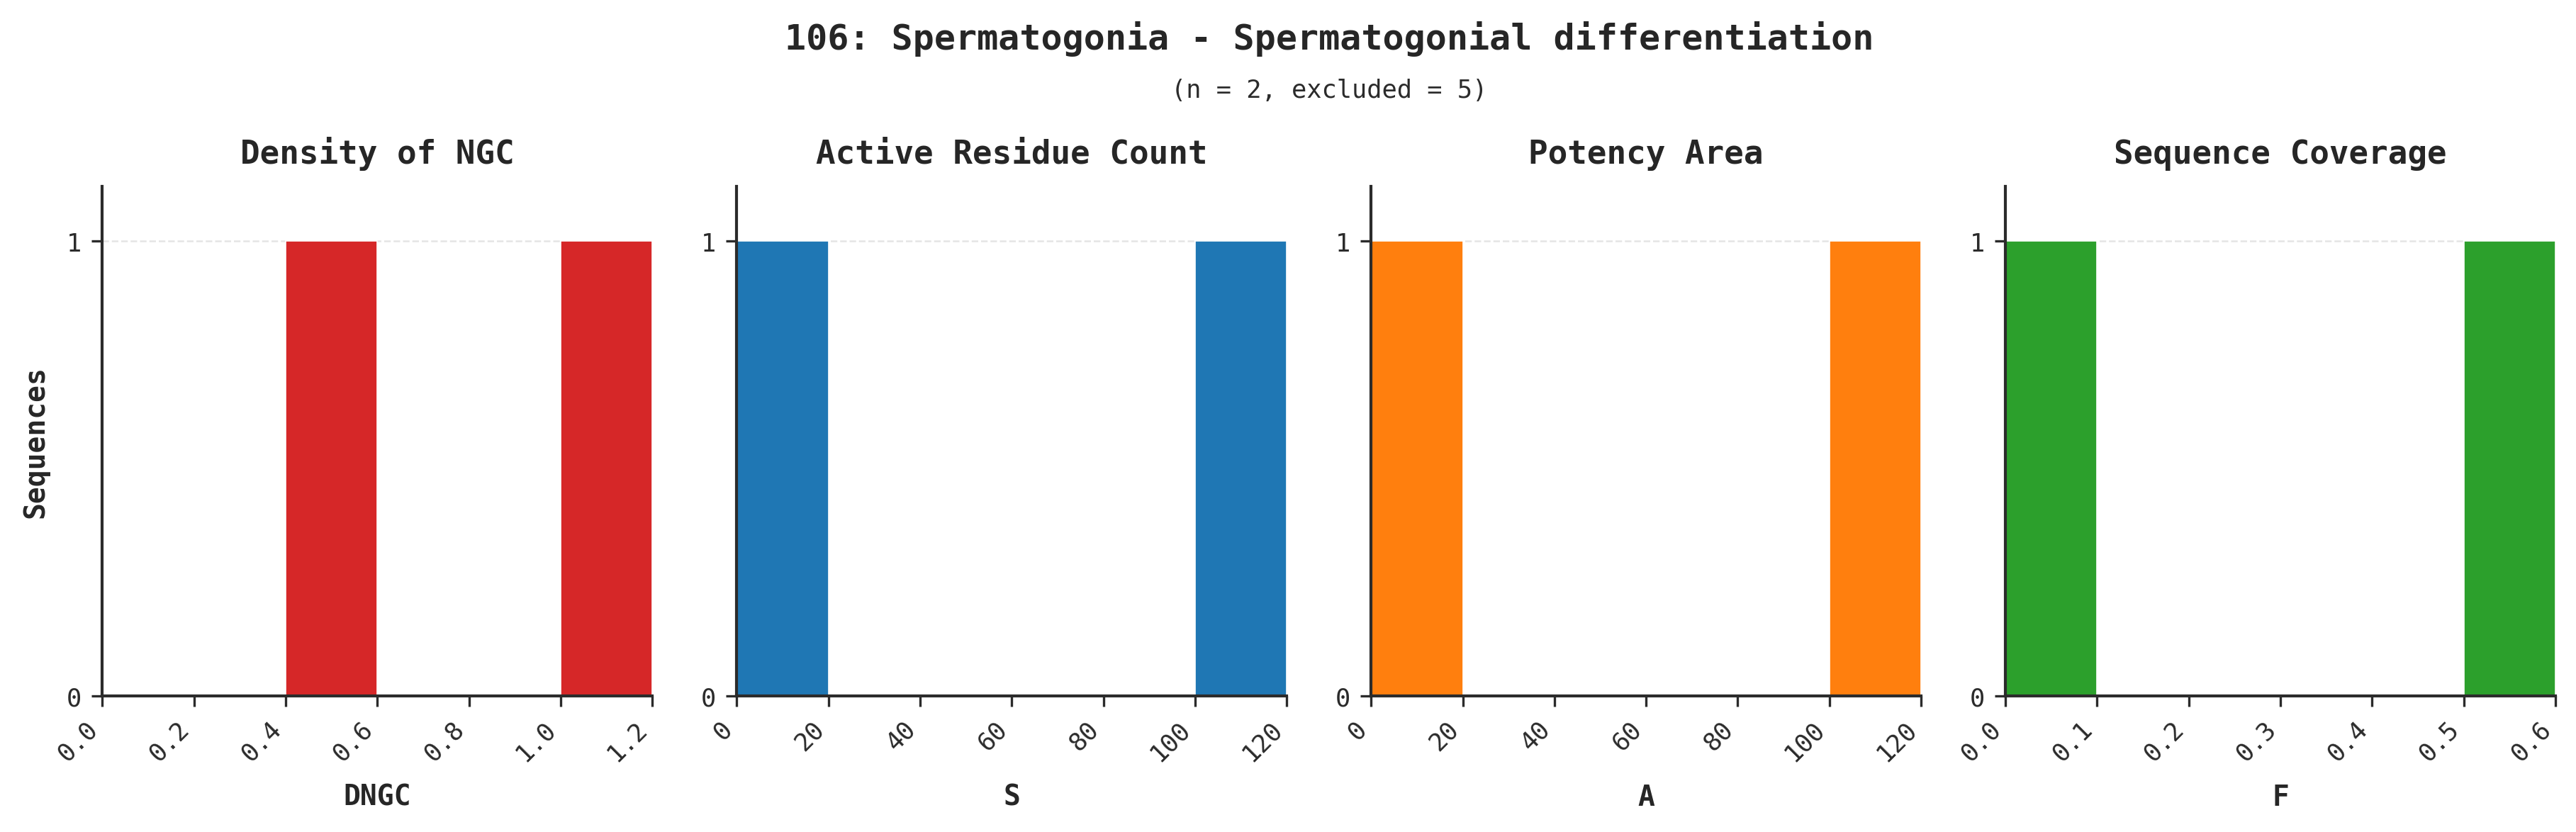

In [4]:
def _nice_bin_width(span: float, target_bins: int = 8) -> float:
    raw = span / max(target_bins, 1)
    if raw <= 0:
        return 1.0
    exponent = np.floor(np.log10(raw))
    fraction = raw / (10 ** exponent)
    if fraction <= 1:
        nice = 1.0
    elif fraction <= 2:
        nice = 2.0
    elif fraction <= 5:
        nice = 5.0
    else:
        nice = 10.0
    return float(nice * (10 ** exponent))


def histogram_bins(values: np.ndarray, target_bins: int = 8) -> np.ndarray:
    finite = values[np.isfinite(values)]
    maximum = float(finite.max()) if finite.size else 0.0
    width = _nice_bin_width(max(maximum, 0.0), target_bins)
    upper = max(width, float(np.ceil(maximum / width) * width)) if width else 1.0
    return np.arange(0.0, upper + width, width)


def _metric_values(group: ClusterGroup, field_name: str) -> np.ndarray:
    return np.asarray(
        [getattr(item.statistics, field_name) for item in group.profiles],
        dtype=np.float64,
    )


def draw_distribution(
    ax,
    values: np.ndarray,
    bins: np.ndarray,
    title: str,
    xlabel: str,
    color: str,
    ylabel: str | None,
) -> int:
    finite = values[np.isfinite(values)]
    heights, _, _ = ax.hist(finite, bins=bins, color=color, edgecolor="white", linewidth=0.4, zorder=2)
    if finite.size and np.allclose(finite, 0.0):
        ax.text(
            0.5,
            0.62,
            f"All {finite.size} sequences are 0",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=8.5,
            color="#666666",
        )
    style_axes(ax, xlabel=xlabel, ylabel=ylabel, title=title, label_size=9.5, title_size=11)
    ax.set_xlim(float(bins[0]), float(bins[-1]))
    ax.set_xticks(bins)
    if len(bins) > 6:
        ax.tick_params(axis="x", labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_ha("right")
    return int(heights.max()) if len(heights) else 0


def add_cluster_heading(header, name: str, subtitle: str) -> None:
    header.axis("off")
    header.set_title(name, fontsize=12, fontweight="bold", pad=20)
    header.annotate(
        subtitle,
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 2),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="normal",
        color=SPINE_COLOR,
        annotation_clip=False,
    )


METRIC_HISTOGRAMS = (
    ("dngc", "Density of NGC", "DNGC", "#d62728"),
    ("s_score", "Active Residue Count", "S", "#1f77b4"),
    ("potency_auc", "Potency Area", "A", "#ff7f0e"),
    ("coverage", "Sequence Coverage", "F", "#2ca02c"),
)


def show_cluster_metric_histograms(group: ClusterGroup) -> None:
    fig = plt.figure(figsize=(12.0, 3.8), dpi=300, layout="constrained")
    grid = fig.add_gridspec(2, len(METRIC_HISTOGRAMS), height_ratios=[0.02, 1.0])
    header = fig.add_subplot(grid[0, :])
    add_cluster_heading(
        header,
        clean_cluster_title(group.name, 90),
        f"(n = {group.n}, excluded = {group.excluded_count})",
    )

    axes = []
    peaks = []
    for index, (field_name, title, xlabel, color) in enumerate(METRIC_HISTOGRAMS):
        ax = fig.add_subplot(grid[1, index], sharey=axes[0] if axes else None)
        axes.append(ax)
        values = _metric_values(group, field_name)
        ylabel = "Sequences" if index == 0 else None
        peaks.append(
            draw_distribution(ax, values, histogram_bins(values), title, xlabel, color, ylabel)
        )

    peak = max(peaks) if peaks else 0
    axes[0].set_ylim(0.0, max(peak, 1) * 1.12)
    axes[0].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    save_cluster_plot(fig, "metric_histograms")
    plt.show()


show_cluster_metric_histograms(example_group)


## Fragment heatmap

Active fragments in this cluster, binned by length and fragment DNGC. Empty bins are left white.


saved /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/results/per_cluster_plots/106/fragment_heatmap.png


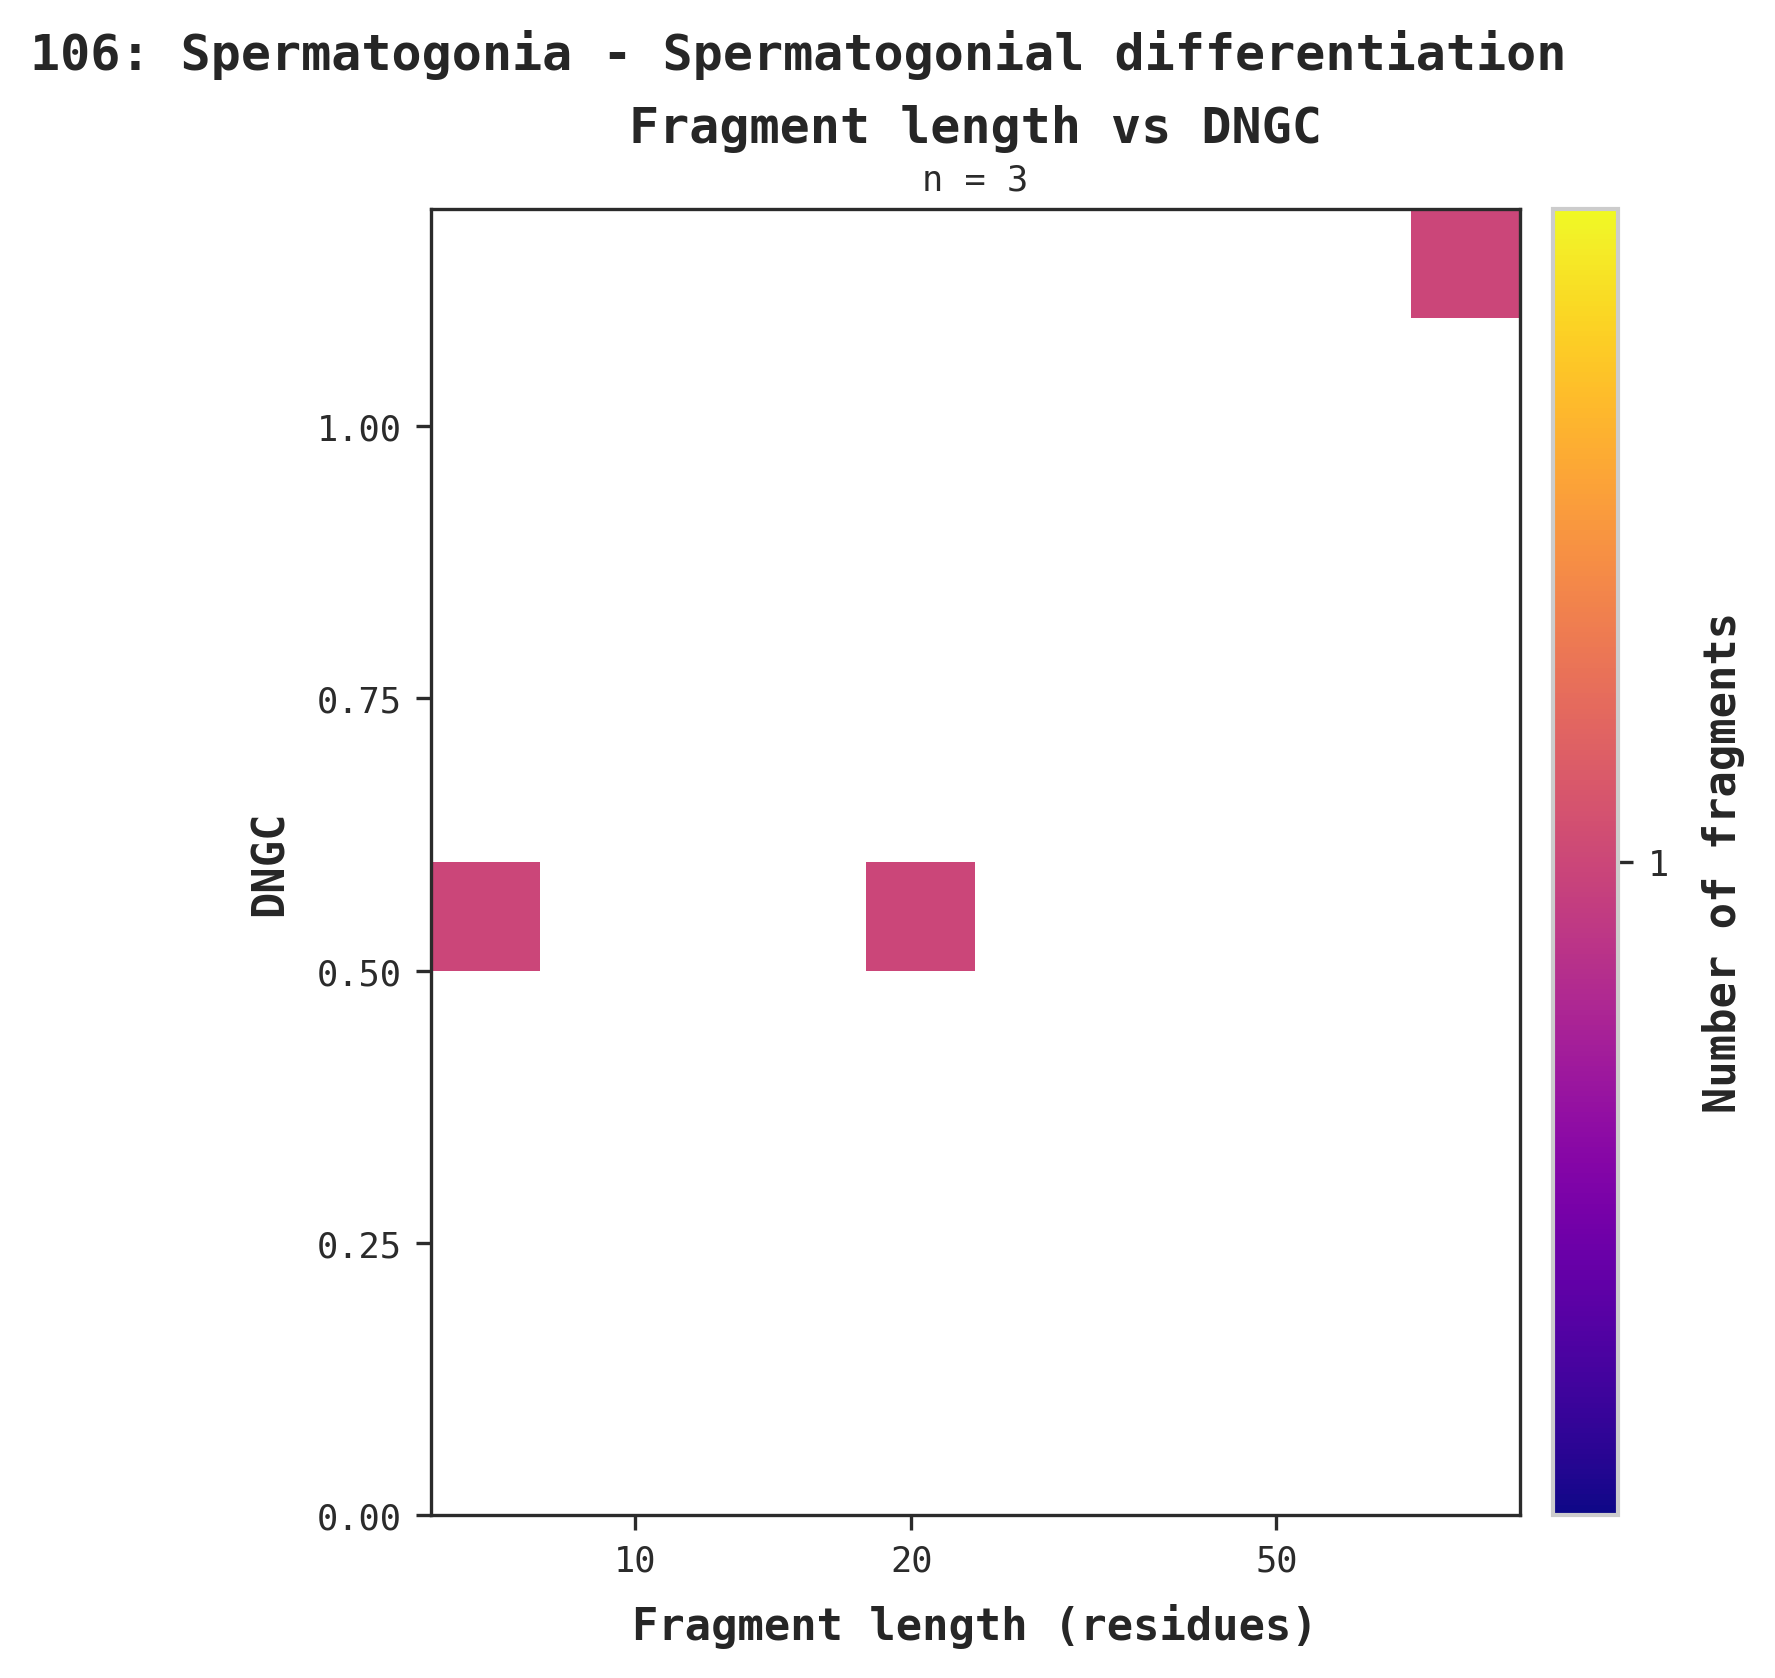

In [5]:
def active_fragment_spans(sigma: np.ndarray, p_amp: np.ndarray) -> list[tuple[int, int, float]]:
    active = activity_mask(sigma, p_amp)
    if active.size == 0 or not np.any(active):
        return []
    padded = np.concatenate([[False], active, [False]])
    changes = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    spans = []
    for start, end in zip(starts, ends):
        segment = sigma[start:end]
        spans.append((int(start), int(end), float(np.sum(segment) / segment.size)))
    return spans


def fragment_length_dngc(group: ClusterGroup) -> tuple[np.ndarray, np.ndarray]:
    lengths: list[float] = []
    scores: list[float] = []
    for item in group.profiles:
        for start, end, score in active_fragment_spans(item.sigma, item.p_amp):
            length = end - start
            if length <= 0 or not np.isfinite(score):
                continue
            lengths.append(float(length))
            scores.append(score)
    return np.asarray(lengths, dtype=np.float64), np.asarray(scores, dtype=np.float64)


def _integer_span_ticks(low: int, high: int) -> list[int]:
    if high < low:
        low, high = high, low
    if high == low:
        return [low]
    raw = MaxNLocator(integer=True, nbins=5, min_n_ticks=2).tick_values(low, high)
    ticks = sorted({int(round(value)) for value in raw if low <= value <= high})
    return ticks or [low, high]


def _log_length_edges(low: float, high: float, bins_per_decade: int = 8) -> np.ndarray:
    low = max(1.0, low)
    high = max(high, low + 1.0)
    n_bins = max(1, int(np.ceil(np.log10(high / low) * bins_per_decade)))
    edges = np.geomspace(low, high, n_bins + 1)
    edges[0] = low
    edges[-1] = high
    return edges


def _integer_tick_label(value: float, _position: object) -> str:
    rounded = int(round(value))
    if rounded < 1 or abs(value - rounded) > 1e-4 * value:
        return ""
    return str(rounded)


def _style_heatmap(ax) -> None:
    ax.set_facecolor("white")
    ax.grid(False)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(0.8)
    ax.tick_params(labelsize=8.5, length=3.5, width=0.8, colors=SPINE_COLOR)


def plot_fragment_length_dngc_heatmap(group: ClusterGroup) -> None:
    lengths, scores = fragment_length_dngc(group)
    if lengths.size == 0:
        _fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=300, layout="constrained")
        _style_heatmap(ax)
        style_axes(ax, xlabel="Fragment length (residues)", ylabel="DNGC", title="No fragments")
        save_cluster_plot(_fig, "fragment_heatmap")
        plt.show()
        return

    x_lo = max(1.0, float(np.floor(lengths.min())))
    x_hi = float(np.ceil(lengths.max()))
    if x_hi <= x_lo:
        x_hi = x_lo + 1.0
    y_hi = float(scores.max())
    y_step = 0.1 if y_hi <= 2.5 else 0.25
    y_hi = float(np.ceil((y_hi + 1e-9) / y_step) * y_step)
    x_edges = _log_length_edges(x_lo, x_hi)
    y_edges = np.arange(0.0, y_hi + y_step * 0.5, y_step)
    n_x = len(x_edges) - 1
    n_y = max(len(y_edges) - 1, 1)
    cell = 0.34
    fig, ax = plt.subplots(
        figsize=(max(6.4, cell * n_x + 1.8), max(4.2, cell * n_y + 1.4)),
        dpi=300,
        layout="constrained",
    )
    _style_heatmap(ax)
    counts, _, _ = np.histogram2d(lengths, scores, bins=[x_edges, y_edges])
    masked = np.ma.masked_where(counts.T == 0, counts.T)
    peak = int(counts.max()) if counts.size else 1
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        masked,
        cmap="plasma",
        vmin=1,
        vmax=max(peak, 1),
        shading="flat",
    )
    colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    colorbar.set_label("Number of fragments", fontsize=10.5, fontweight="bold", labelpad=8)
    count_ticks = _integer_span_ticks(1, max(peak, 1))
    colorbar.set_ticks(count_ticks)
    colorbar.ax.tick_params(labelsize=8.5, length=3.5, width=0.8, colors=SPINE_COLOR)

    ax.set_xscale("log")
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.set_box_aspect(n_y / n_x)
    ax.margins(x=0, y=0)
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.xaxis.set_major_formatter(FuncFormatter(_integer_tick_label))
    ax.xaxis.minorticks_off()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, min_n_ticks=2))
    ax.set_xlabel("Fragment length (residues)", fontsize=10.5, fontweight="bold", labelpad=6)
    ax.set_ylabel("DNGC", fontsize=10.5, fontweight="bold", labelpad=6)
    ax.set_title("Fragment length vs DNGC", fontsize=12, fontweight="bold", pad=16)
    ax.annotate(
        f"n = {int(lengths.size)}",
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="normal",
        color=SPINE_COLOR,
        annotation_clip=False,
    )
    fig.suptitle(clean_cluster_title(group.name, 80), fontsize=12, fontweight="bold")
    save_cluster_plot(fig, "fragment_heatmap")
    plt.show()


plot_fragment_length_dngc_heatmap(example_group)


## Sequence heatmap

Top 10 sequences by DNGC, one row each. The x-axis is the residue number, so tracks stay in register and are not scaled to length or percent. Color is positive σNGC on the magma scale: stronger color is higher net positive potency, and positions without it are white.


saved /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/results/per_cluster_plots/106/sequence_heatmap.png


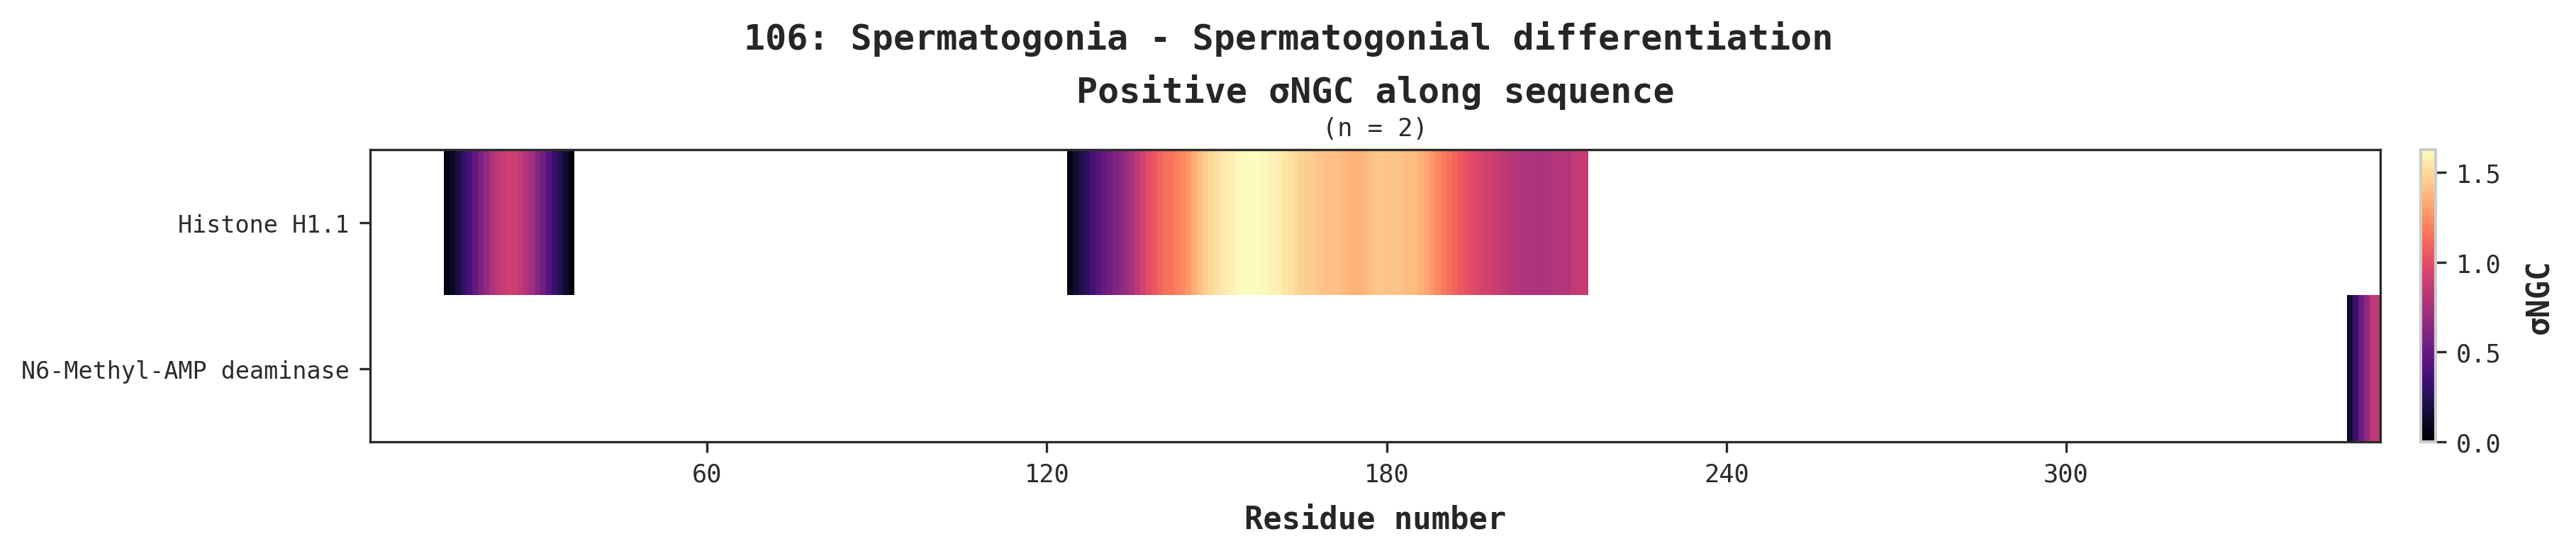

In [6]:
TOP_DNGC_TRACKS = 10


def top_profiles_by_dngc(group: ClusterGroup, limit: int = TOP_DNGC_TRACKS) -> list[SequenceProfile]:
    ranked = sorted(group.profiles, key=lambda item: (-item.statistics.dngc, item.name))
    return ranked[:limit]


def positive_sigma_matrix(profiles: list[SequenceProfile]) -> np.ndarray:
    width = max(item.sequence_length for item in profiles)
    matrix = np.full((len(profiles), width), np.nan, dtype=np.float64)
    for index, item in enumerate(profiles):
        excess = item.sigma - SIGMA_ACTIVITY_THRESHOLD
        active = activity_mask(item.sigma, item.p_amp)
        count = min(width, excess.size)
        positive = active[:count] & np.isfinite(excess[:count]) & (excess[:count] > 0)
        matrix[index, :count] = np.where(positive, excess[:count], np.nan)
    return matrix


def _potency_colorbar(fig, ax, image) -> None:
    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label("σNGC", fontsize=10.5, fontweight="bold", labelpad=8)
    colorbar.ax.tick_params(labelsize=8.5, length=3.5, width=0.8, colors=SPINE_COLOR)


def plot_top_sequence_heatmap(group: ClusterGroup) -> None:
    profiles = top_profiles_by_dngc(group)
    if not profiles:
        _fig, ax = plt.subplots(figsize=(12.0, 3.2), dpi=300, layout="constrained")
        _style_heatmap(ax)
        style_axes(ax, xlabel="Residue number", title="No sequences")
        save_cluster_plot(_fig, "sequence_heatmap")
        plt.show()
        return

    matrix = positive_sigma_matrix(profiles)
    width = matrix.shape[1]
    row_count = len(profiles)
    peak = float(np.nanmax(matrix)) if np.isfinite(matrix).any() else 1.0
    fig, ax = plt.subplots(
        figsize=(12.0, max(2.5, 0.18 * row_count + 1.2)),
        dpi=300,
        layout="constrained",
    )
    _style_heatmap(ax)
    image = ax.imshow(
        np.ma.masked_invalid(matrix),
        cmap="magma",
        vmin=0.0,
        vmax=max(peak, 1e-6),
        aspect="auto",
        interpolation="nearest",
        origin="upper",
        extent=(0.5, width + 0.5, row_count - 0.5, -0.5),
    )
    _potency_colorbar(fig, ax, image)
    ax.set_yticks(np.arange(row_count))
    ax.set_yticklabels([item.name or item.id for item in profiles], fontsize=8)
    ax.set_xlim(0.5, width + 0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6, min_n_ticks=2))
    ax.set_xlabel("Residue number", fontsize=10.5, fontweight="bold", labelpad=6)
    ax.set_title("Positive σNGC along sequence", fontsize=12, fontweight="bold", pad=16)
    ax.annotate(
        f"(n = {row_count})",
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="normal",
        color=SPINE_COLOR,
        annotation_clip=False,
    )
    fig.suptitle(clean_cluster_title(group.name, 80), fontsize=12, fontweight="bold")
    save_cluster_plot(fig, "sequence_heatmap")
    plt.show()


plot_top_sequence_heatmap(example_group)
